# Shallow 1 Dimension Convolutional Network

- splitto train, val, test
- data augmentation sul train set originale con step e linear
- scaling fit su train e transform su validation/test
- creazione tabella lag features con sequenze su tutti i set
- reshape per CNN: da (samples, timesteps) a (samples, timesteps, 1) [1 perchè univariato]

In [16]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [35]:
from src.config import set_seeds, get_complete_path, MODELS_DIR
import src.pipeline as pipe
import src.models as mod
import src.models.nn as nn
import src.evaluation as eval
import src.visualization as visual
import src.reporting as rep
import pandas as pd
import tensorflow as tf
import os
import gc
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping # type: ignore

In [19]:
set_seeds()

In [20]:
INDICATORS = ['Fertilizer consumption (% of fertilizer production)']

In [21]:
df = pipe.load_data()

Dataset caricato: 65 anni, 28 variabili.


============================== FERTILIZER CONSUMPTION (% OF FERTILIZER PRODUCTION) ==============================
Train: 1961-2003 (43 obs)
Val:   2004-2013 (10 obs)
Test:  2014-2022 (9 obs)
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\AUGMENTATION\AUG_fertilizer_percent.png


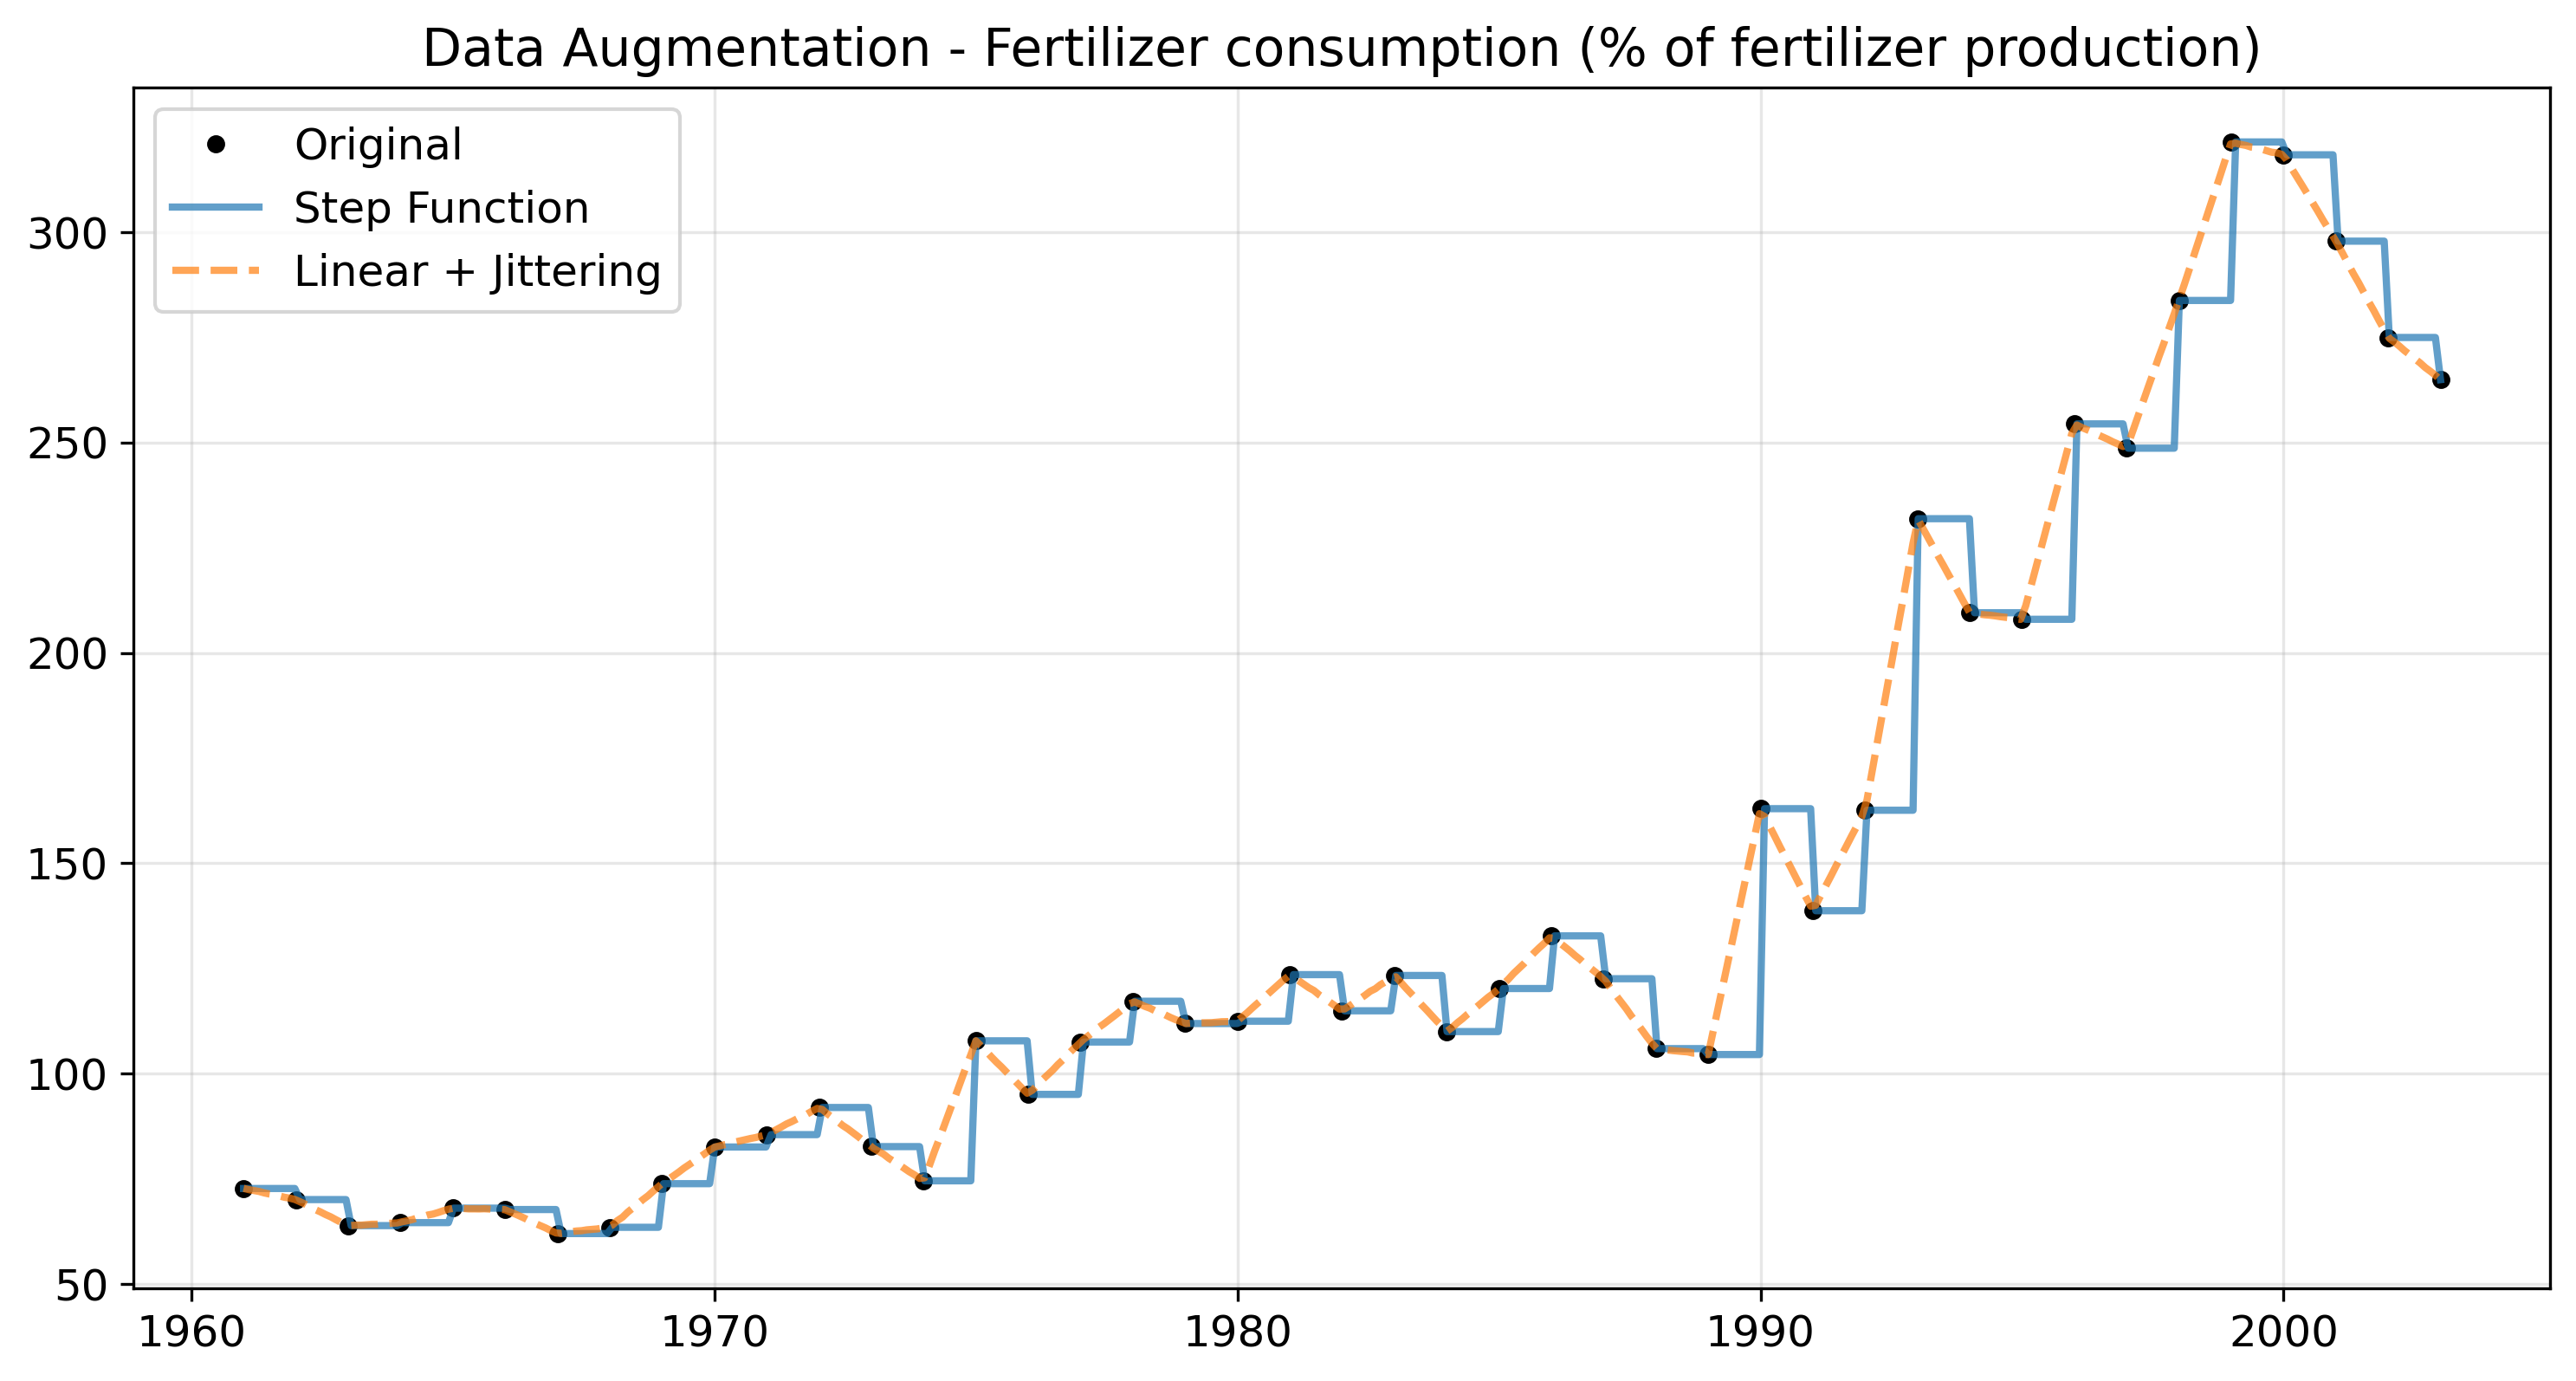

In [22]:
orig_aug_subsets = {}

for indicator in INDICATORS:
    print('='*30, indicator.upper(), '='*30)
    df_temp = df[['Year', indicator]].dropna().copy()
    df_temp.columns = ['Year', 'Value']
    train_orig, val_orig, test_orig = pipe.split_train_val_test(df_temp)    # splitto la time serie ORIGINALE
    
    x_train_vals = train_orig['Year']
    y_train_vals = train_orig['Value']
    
    df_step = pipe.augment_step_function(x_train_vals, y_train_vals, scale_factor=10)
    df_jitter = pipe.augment_linear_with_jitter(x_train_vals, y_train_vals, scale_factor=10, noise_level=0.05)
    visual.plot_augmented(indicator, df_step, df_jitter, x_train_vals, y_train_vals)
    orig_aug_subsets[indicator] = {
        'full_orig': df_temp,
        'orig_train': train_orig,
        'step_aug_train': df_step,
        'jitter_aug_train': df_jitter,
        'orig_val': val_orig,
        'orig_test': test_orig
    }

In [23]:
scaled_orig_aug_subsets = {} 
scalers_subsets = {}
for indicator in INDICATORS:
    scaled_subsets, scalers = pipe.scale_datasets(orig_aug_subsets[indicator])
    scaled_orig_aug_subsets[indicator] = scaled_subsets
    scalers_subsets[indicator] = scalers

In [24]:
scaled_table_subsets = {}
for indicator in INDICATORS:
    window_size = 3
    table_train_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_train'], window_size, step=1)
    table_train_step = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['step_aug_train'], window_size, step=1)
    table_train_jitter = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['jitter_aug_train'], window_size, step=1)
    table_val_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_val'], window_size, step=1)
    table_test_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_test'], window_size, step=1)
    scaled_table_subsets[indicator] = {
        'train_orig' : table_train_orig,
        'train_step' : table_train_step,
        'train_jitter' : table_train_jitter,
        'val_orig' : table_val_orig,
        'test_orig' : table_test_orig
    }

## Reshape

In [25]:
final_table_train_sets = {}
final_table_val_test_sets = {}

for indicator in INDICATORS:
    # X: filtra colonne ts_*
    # y: prende colonna 'target'
    X_train_orig_to_reshape = scaled_table_subsets[indicator]['train_orig'].filter(regex=r'^ts_').copy()
    y_train_orig_to_reshape = scaled_table_subsets[indicator]['train_orig']['target'].copy()
    
    X_train_step_to_reshape = scaled_table_subsets[indicator]['train_step'].filter(regex=r'^ts_').copy()
    y_train_step_to_reshape = scaled_table_subsets[indicator]['train_step']['target'].copy()
    
    X_train_jitter_to_reshape = scaled_table_subsets[indicator]['train_jitter'].filter(regex=r'^ts_').copy()
    y_train_jitter_to_reshape = scaled_table_subsets[indicator]['train_jitter']['target'].copy()
    
    X_val_orig_to_reshape = scaled_table_subsets[indicator]['val_orig'].filter(regex=r'^ts_').copy()
    y_val_orig_to_reshape = scaled_table_subsets[indicator]['val_orig']['target'].copy()
    
    X_test_orig_to_reshape = scaled_table_subsets[indicator]['test_orig'].filter(regex=r'^ts_').copy()
    y_test_orig_to_reshape = scaled_table_subsets[indicator]['test_orig']['target'].copy()
    
    # Reshape X: (samples, window_size, 1)
    X_train_orig = X_train_orig_to_reshape.values.reshape((X_train_orig_to_reshape.shape[0], X_train_orig_to_reshape.shape[1], 1))
    X_train_step = X_train_step_to_reshape.values.reshape((X_train_step_to_reshape.shape[0], X_train_step_to_reshape.shape[1], 1))
    X_train_jitter = X_train_jitter_to_reshape.values.reshape((X_train_jitter_to_reshape.shape[0], X_train_jitter_to_reshape.shape[1], 1))
    X_val_orig = X_val_orig_to_reshape.values.reshape((X_val_orig_to_reshape.shape[0], X_val_orig_to_reshape.shape[1], 1))
    X_test_orig = X_test_orig_to_reshape.values.reshape((X_test_orig_to_reshape.shape[0], X_test_orig_to_reshape.shape[1], 1))
    
    # Reshape y: (samples, 1)
    y_train_orig = y_train_orig_to_reshape.values.reshape(-1, 1)
    y_train_step = y_train_step_to_reshape.values.reshape(-1, 1)
    y_train_jitter = y_train_jitter_to_reshape.values.reshape(-1, 1)
    y_val_orig = y_val_orig_to_reshape.values.reshape(-1, 1)
    y_test_orig = y_test_orig_to_reshape.values.reshape(-1, 1)
    
    final_table_train_sets[indicator] = {
        'train_orig' : (X_train_orig, y_train_orig),
        'train_step' : (X_train_step, y_train_step),
        'train_jitter' : (X_train_jitter, y_train_jitter),
    }
    
    final_table_val_test_sets[indicator] = {
        'val_orig': (X_val_orig, y_val_orig),
        'test_orig' : (X_test_orig, y_test_orig)
    }
    
    print("train orig", X_train_orig[0], y_train_orig[0])
    print("step", X_train_step[0], y_train_step[0])
    print("jitter", X_train_jitter[0], y_train_jitter[0])
    print("val", X_val_orig[0], y_val_orig[0])
    print("test", X_test_orig[0], y_test_orig[0])

train orig [[0.04129761]
 [0.03113621]
 [0.00728706]] [0.01002216]
step [[0.04129761]
 [0.04129761]
 [0.04129761]] [0.04129761]
jitter [[0.04139334]
 [0.04027614]
 [0.03943279]] [0.03860666]
val [[0.60687893]
 [0.97236234]
 [1.3102521 ]] [3.09437738]
test [[0.58642959]
 [0.61787725]
 [0.49408046]] [0.65113174]


Parametri Architetturali
- n_filters: numero di filtri Conv1D (es. 32, 64, 128)
- kernel_size: dimensione kernel convoluzionale (es. 3, 5)
- n_conv_layers: numero di layer convoluzionali (es. 1-3 per shallow)
- pool_size: dimensione MaxPooling (es. 2)
- dense_units: neuroni nel layer Dense dopo Flatten (opzionale)
- dropout: tasso dropout per regolarizzazione
- activation: funzione attivazione ('relu', 'tanh')

Parametri Training (già gestiti da train_model)
- learning_rate, batch_size, epochs, patience

In [36]:
results = {} 
best_model_paths = {}

params_shallow_cnn = {
    'n_filters': 32,        # numero di filtri conv1D (32, 64, 128)
    'kernel_size': 3,       # dimensione kernel convoluzionale (3,5)
    'n_conv_layers': 1,     # numero di layer convoluzionali (1-3 per shallow)
    'pool_size': 2,         # dimensione MaxPooling (2)
    'use_pooling': False,   # if True usa MaxPooling, per time serie corte provo a mettere false
    'dense_units': 50,      # neuroni nel layer Dense dopo Flatten
    'dropout': 0.2,         # tasso dropout per regolarizzazione
    'activation': 'relu',   # funzione di attivazione (relu, tanh)
    'learning_rate': 0.001  # usato da train_model
}

for indicator in INDICATORS:
    if indicator not in results:
        results[indicator] = {}
    if indicator not in best_model_paths:
        best_model_paths[indicator] = {}
    
    for ds_category in ['orig', 'step', 'jitter']:
        print(f"Processing: {indicator} | ds_category: {ds_category}")
        
        X_train = final_table_train_sets[indicator][f'train_{ds_category}'][0]
        y_train = final_table_train_sets[indicator][f'train_{ds_category}'][1]

        X_val = final_table_val_test_sets[indicator]['val_orig'][0]
        y_val = final_table_val_test_sets[indicator]['val_orig'][1]
        
        X_test = final_table_val_test_sets[indicator]['test_orig'][0]        
        y_test = final_table_val_test_sets[indicator]['test_orig'][1]
        
        scaler = scalers_subsets[indicator]['scaler_y']
        
        model_name = f"shallowCNN_{ds_category}" 
        path = get_complete_path(MODELS_DIR, model_name, indicator, ext=".keras")
        
        best_model_paths[indicator][ds_category] = path
        
        checkpoint = ModelCheckpoint(
            path, 
            monitor='val_loss', 
            save_best_only=True,
            mode='min', 
            verbose=0
        )
        
        input_shape = (X_train.shape[1], X_train.shape[2]) 
        model = nn.build_cnn_model(params_shallow_cnn, input_shape)
        
        history, trained_model = nn.train_model(
            model, 
            X_train, y_train,
            X_val, y_val,
            batch_size=8,
            epochs=100,
            patience=15,
            extra_callbacks=[checkpoint]
        )
        
        pred_scaled = trained_model.predict(X_test, verbose=0)
        
        test_real = scaler.inverse_transform(y_test.reshape(-1, 1))
        pred_real = scaler.inverse_transform(pred_scaled)
        
        results[indicator][ds_category] = {
            'test_real': test_real,
            'pred_real': pred_real,
            'history': history.history['loss'],
            'metrics': eval.compute_errors(test_real, pred_real)
        }
        
        tf.keras.backend.clear_session()
        del model
        del trained_model
        gc.collect()

Processing: Fertilizer consumption (% of fertilizer production) | ds_category: orig
Processing: Fertilizer consumption (% of fertilizer production) | ds_category: step
Processing: Fertilizer consumption (% of fertilizer production) | ds_category: jitter


Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\CNN_shallow\cnn_shallow_fertilizer_percent.png


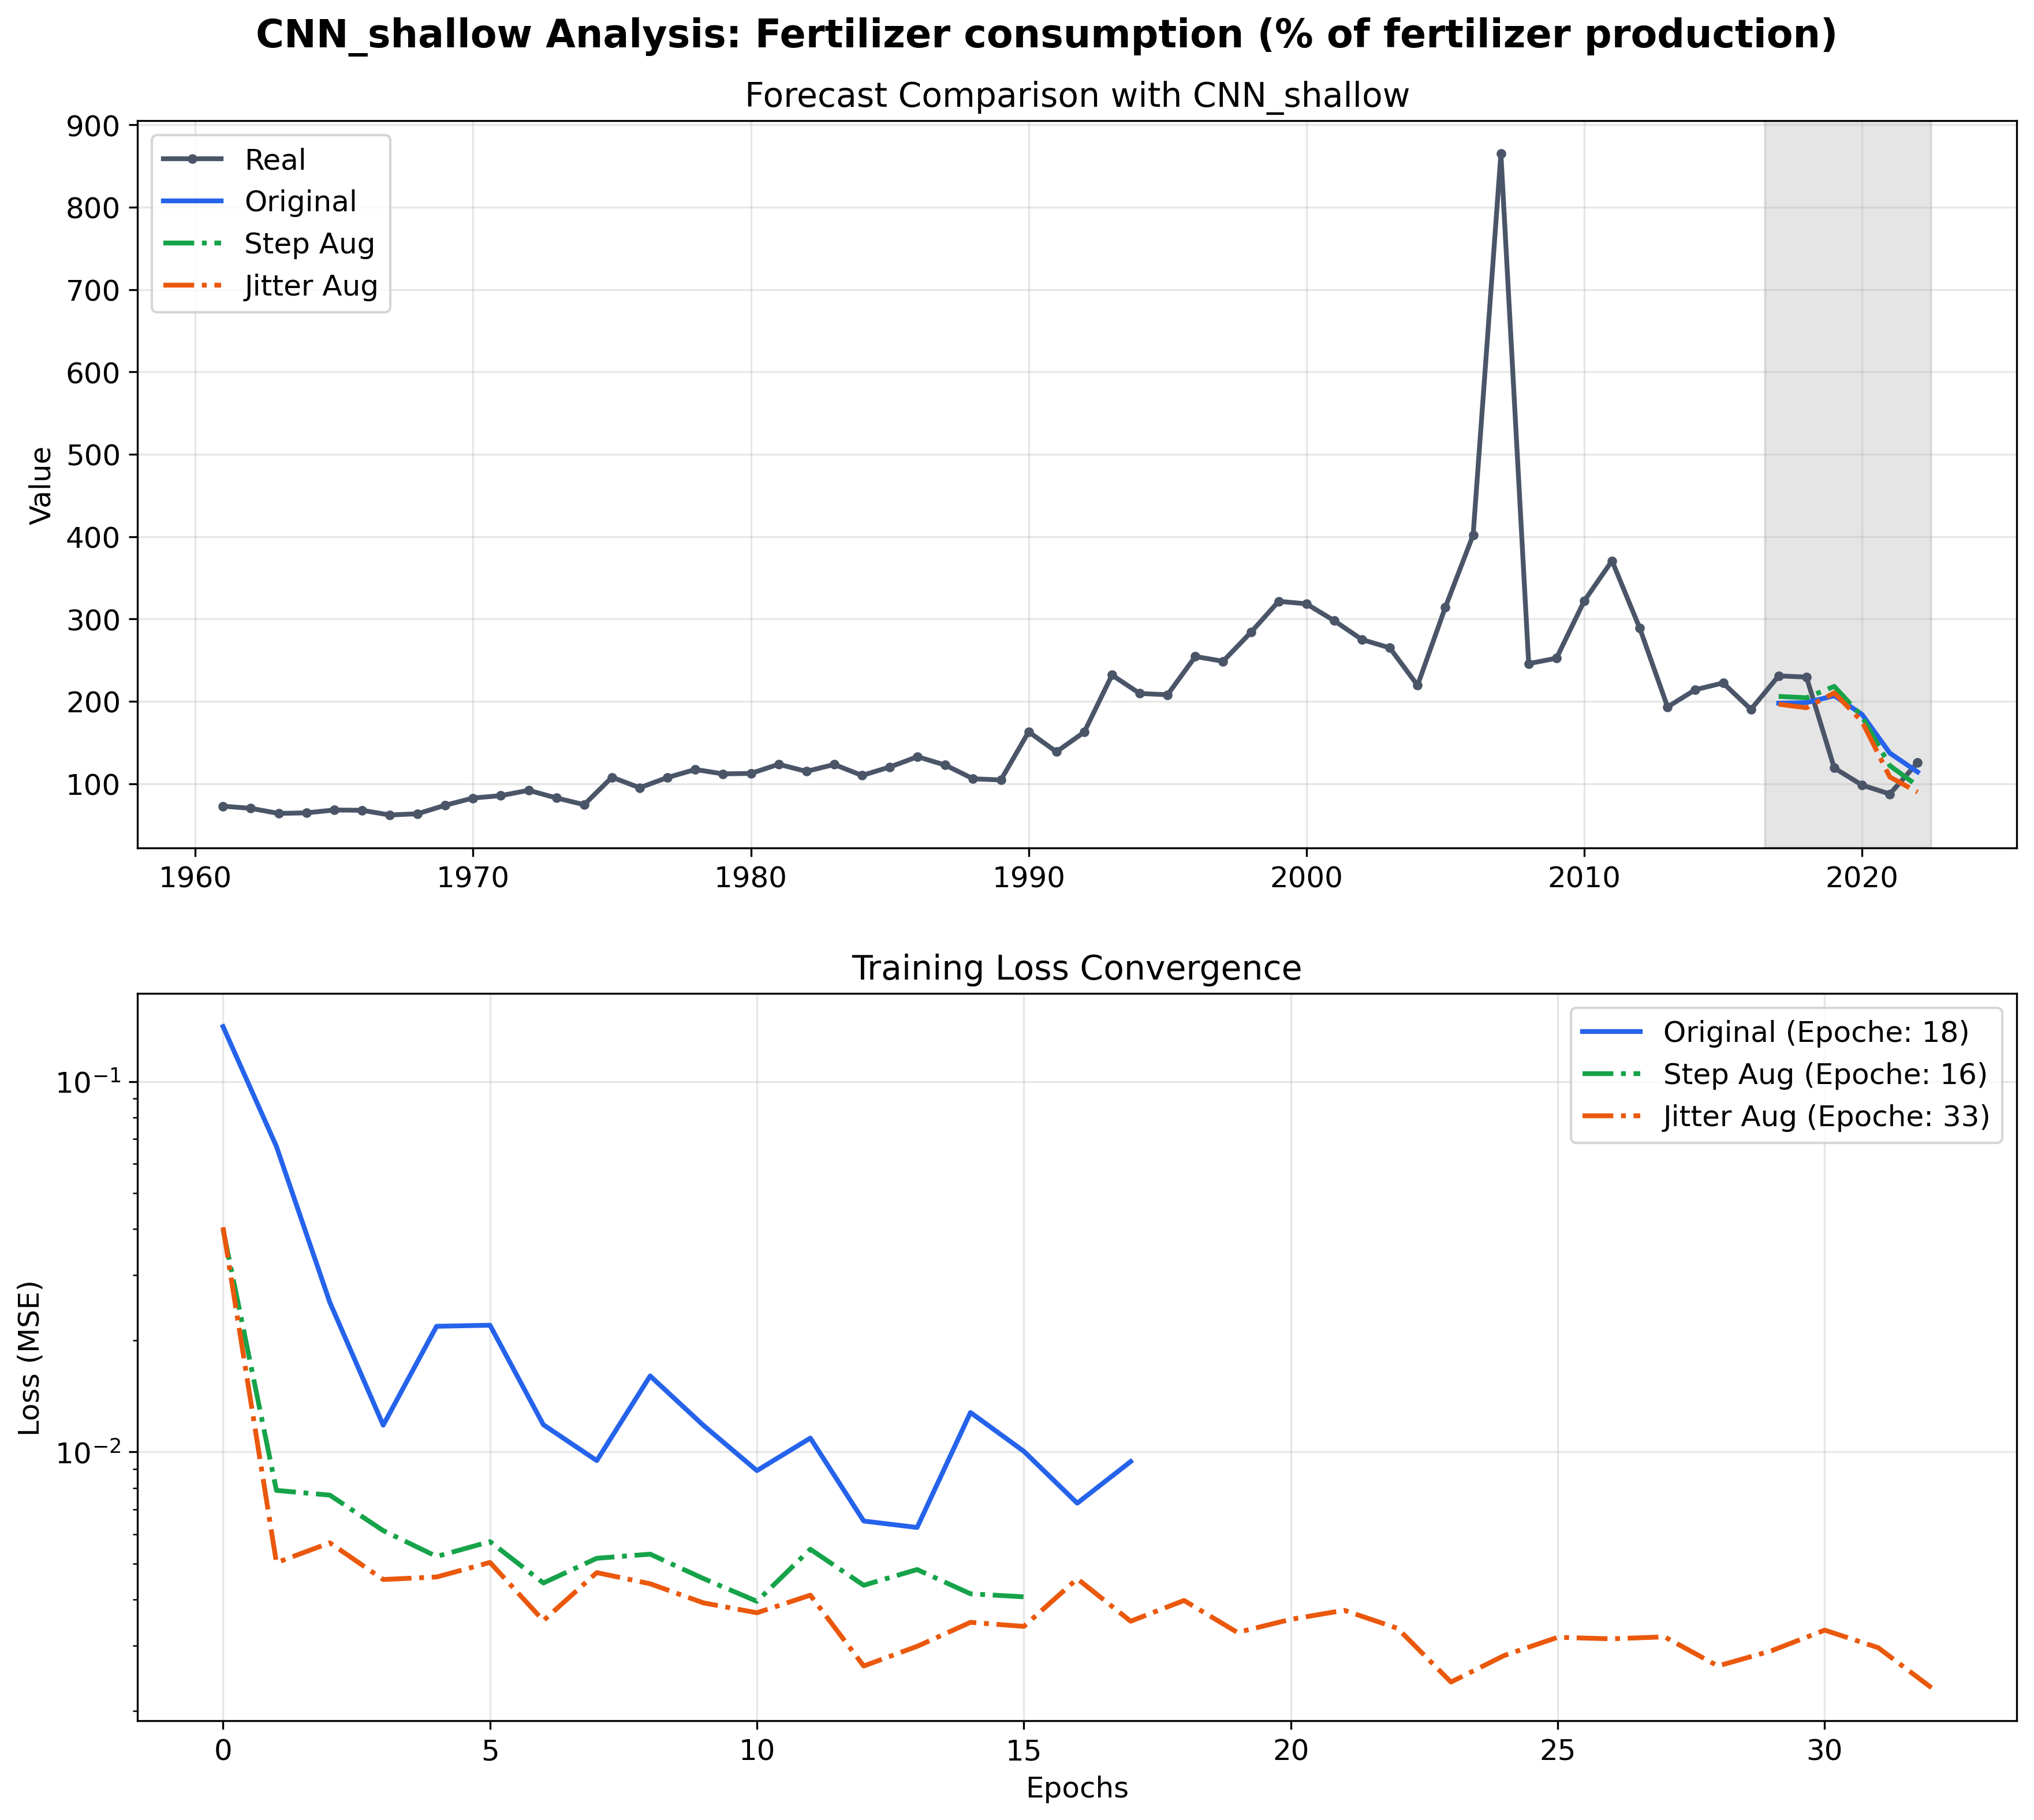

In [37]:
visual.plot_shallow_nn_preds(indicator, results, orig_aug_subsets, model_name="CNN_shallow")

In [ ]:
for indicator in INDICATORS:
    best_model_paths[indicator] = {}
    
    # Per il forecasting finale, spesso ci interessa il modello trainato sui dati 'original'
    # o sulla augmentation che ha performato meglio. Qui salvo per tutti.
    for augmentation in ['original', 'step', 'jitter']:
        print(f"--- Training: {indicator} | {augmentation} ---")
        
        # ... (Il tuo codice di caricamento dati X, y, X_val, y_val rimane uguale) ...
        # X = ...
        # y = ...
        
        # 1. Definizione nome file unico per questo modello
        # Pulisci il nome dell'indicatore per evitare errori nel file system
        safe_name = indicator[:20].replace(" ", "_").replace("/", "")
        model_filename = os.path.join(MODELS_DIR, f"best_cnn_{safe_name}_{augmentation}.keras")
        
        # 2. Setup della Callback per salvare SOLO il migliore
        
        # 3. Build del Modello
        input_shape = (X.shape[1], X.shape[2]) 
        model = nn.build_cnn_model(params_shallow_cnn, input_shape)

        # 4. Fit con le callback
        history = model.fit(
            X, y,
            validation_data=(X_val, y_val),
            batch_size=8,
            epochs=100,
            callbacks=[early_stop, checkpoint],
            verbose=0
        )
        
        model_path = get_complete_path(
            base_dir=MODELS_DIR, 
            model_name="CNN_Shallow", 
            variable_name=indicator, 
            ext=".keras"
        )

        checkpoint = ModelCheckpoint(model_path, save_best_only=True, ...)
        
        # Salviamo il percorso nel dizionario per usarlo dopo
        best_model_paths[indicator][augmentation] = model_filename
        
        # Pulizia memoria
        tf.keras.backend.clear_session()

print("Training completato. Modelli migliori salvati.")

In [ ]:
nn.recursive_forecast(model,)